C:\Users\Black Hawk\AppData\Local\Temp\ipykernel_15496\3366442020.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], parse_dates=[['Date', 'Time']], infer_datetime_format=True)
C:\Users\Black Hawk\AppData\Local\Temp\ipykernel_15496\3366442020.py:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], parse_dates=[['Date', 'Time']], infer_datetime_format=True)
C:\Users\Black Hawk\AppData\Local\Temp\ipykernel_15496\3366442020.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=Fals

ARIMA  | MAE: 0.670 | RMSE: 0.829
Prophet| MAE: 0.563 | RMSE: 0.728
XGBoost| MAE: 0.500 | RMSE: 0.704


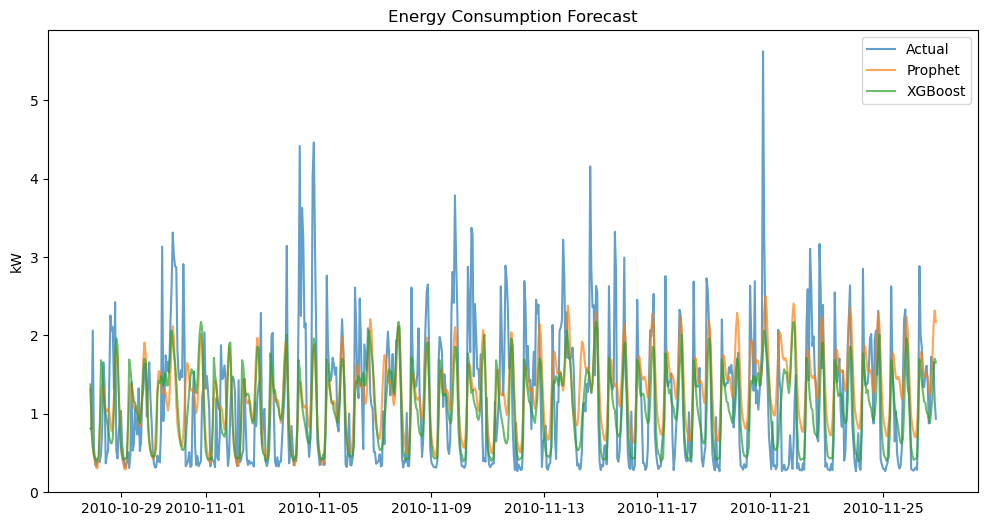

In [2]:
# task3_energy_forecasting.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb

# 1. Parse & Resample
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], parse_dates=[['Date', 'Time']], infer_datetime_format=True)
df = df.dropna()
df['DateTime'] = pd.to_datetime(df['Date_Time'])
df.set_index('DateTime', inplace=True)
df = df[['Global_active_power']].astype(float)
df = df.resample('H').mean().dropna()

# 2. Time Features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df.index.dayofweek >= 5

# 3. Model Comparison
train = df.iloc[:-720]
test = df.iloc[-720:]

# ARIMA
arima = ARIMA(train['Global_active_power'], order=(1,1,1))
arima_res = arima.fit()
arima_pred = arima_res.forecast(steps=720)
arima_mae = mean_absolute_error(test['Global_active_power'], arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test['Global_active_power'], arima_pred))

# Prophet
prophet_df = pd.DataFrame({'ds': train.index, 'y': train['Global_active_power'].values})
model_p = Prophet(daily_seasonality=True, weekly_seasonality=True)
model_p.fit(prophet_df)
future = model_p.make_future_dataframe(periods=720, freq='H')
prophet_pred = model_p.predict(future)['yhat'].iloc[-720:].values
p_mae = mean_absolute_error(test['Global_active_power'], prophet_pred)
p_rmse = np.sqrt(mean_squared_error(test['Global_active_power'], prophet_pred))

# XGBoost
X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']
X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"ARIMA  | MAE: {arima_mae:.3f} | RMSE: {arima_rmse:.3f}")
print(f"Prophet| MAE: {p_mae:.3f} | RMSE: {p_rmse:.3f}")
print(f"XGBoost| MAE: {xgb_mae:.3f} | RMSE: {xgb_rmse:.3f}")

# 4. Plot Actual vs Forecasted
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Global_active_power'], label='Actual', alpha=0.7)
plt.plot(test.index, prophet_pred, label='Prophet', alpha=0.7)
plt.plot(test.index, xgb_pred, label='XGBoost', alpha=0.7)
plt.legend(); plt.title('Energy Consumption Forecast'); plt.ylabel('kW'); plt.show()